In [1]:
import numpy as np
import heapq
from benchmark import *
def as_bits01(a):
    a = np.asarray(a)
    if a.dtype.kind in "fc":
        a = (a > 0.5).astype(np.uint8)
    else:
        a = (a.astype(np.int64) & 1).astype(np.uint8)
    return a

def compute_b_nm(a):
    """
    Newman–Moore down-triangle defect (plaquette) field:
      b[i,j] = a[i,j] xor a[i+1,j] xor a[i+1,j+1]
    periodic boundaries.
    """
    a = as_bits01(a)
    a_i1_j  = np.roll(a, -1, axis=0)
    a_i1_j1 = np.roll(a_i1_j, -1, axis=1)
    return a ^ a_i1_j ^ a_i1_j1


![Alt text](image.png)

In [2]:
import numpy as np

TRI6 = [
    (-1, -1),  # tri 1
    (-1, 0),   # tri 2
    (0, +1),   # tri 3
    (+1, +1),  # tri 4
    (+1, 0),   # tri 5 
    (0, -1),   # tri 6
    
    
]

def init_messages(Lx, Ly, n_dirs=6):
    """
    Initialize message field.

    Returns
    -------
    msg : ndarray, shape (n_dirs, Lx, Ly)
        -1 means 'no message present'
    """
    return -np.ones((n_dirs, Lx, Ly), dtype=np.int16)


def step_msgs_emit_from_defects(msg, syndrome, directions=TRI6, cap=10):
    syndrome = (np.asarray(syndrome, dtype=np.uint8) & 1)
    msg = np.asarray(msg, dtype=np.int16)

    n_dirs, Lx, Ly = msg.shape
    assert n_dirs == len(directions), "Number of message layers must match directions"
    assert syndrome.shape == (Lx, Ly), "syndrome shape must match spatial dimensions"

    big = cap + 1

    # Replace -1 by a large sentinel so min() works cleanly
    msg_work = np.where(msg >= 0, msg, big).astype(np.int16)

    out = np.full_like(msg_work, big)

    for d, (dx, dy) in enumerate(directions):
        # Messages at upstream sites propagate into current site.
        # If a message travels along (dx, dy), then to compute arrivals at (i,j),
        # we pull from (i-dx, j-dy).
        propagated = np.roll(msg_work[d], shift=(dx, dy), axis=(0, 1))

        # Increment propagated distance by 1, but keep "no message" as big
        propagated = np.where(propagated < big, np.minimum(propagated + 1, big), big)

        # Fresh emission from syndrome sites: value 1
        emitted = np.where(syndrome == 1, 1, big).astype(np.int16)

        # Keep the smaller arriving message
        out[d] = np.minimum(propagated, emitted)

    # Convert sentinel back to -1
    out = np.where(out <= cap, out, -1).astype(np.int16)
    return out

In [3]:
import numpy as np
from math import gcd

TRI6 = [
    (+1, +1),  # tri 1
    (+1, 0),   # tri 2
    (0, -1),   # tri 3
    (-1, -1),  # tri 4
    (-1, 0),   # tri 5
    (0, +1),   # tri 6 
]

def orbit_length(Lx, Ly, dx, dy):
    def period_1d(L, d):
        d %= L
        if d == 0:
            return 1
        return L // gcd(L, d)
    return np.lcm(period_1d(Lx, dx), period_1d(Ly, dy))


def build_msgs_stop_at_defects(b, directions=TRI6, cap=10):
    """
    Build one collapsed message field per direction.

    Rule:
      - each defect launches an independent ray in each direction
      - the first site reached gets value 1, then 2, then 3, ...
      - when the ray hits a defect (including wrapping back to its own source),
        that hit site gets the value and the ray stops
      - all rays are then collapsed by taking the minimum value per site

    Parameters
    ----------
    b : ndarray, shape (Lx, Ly)
        Defect field 0/1.
    directions : list of (dx, dy)
        Direction vectors.
    cap : int
        Maximum propagated distance to keep.

    Returns
    -------
    msg : ndarray, shape (n_dirs, Lx, Ly), dtype int16
        -1 means unreached.
        Positive integers are message values.
    """
    b = (np.asarray(b, dtype=np.uint8) & 1)
    Lx, Ly = b.shape
    n_dirs = len(directions)

    big = cap + 1
    msg = np.full((n_dirs, Lx, Ly), big, dtype=np.int16)

    sources = np.argwhere(b == 1)

    for d, (dx, dy) in enumerate(directions):
        T = orbit_length(Lx, Ly, dx, dy)
        max_steps = min(cap, T)

        for sx, sy in sources:
            for dist in range(1, max_steps + 1):
                x = (sx + dist * dx) % Lx
                y = (sy + dist * dy) % Ly

                if dist < msg[d, x, y]:
                    msg[d, x, y] = dist

                # stop this source-ray once it hits any defect
                if b[x, y] == 1:
                    break

    msg = np.where(msg <= cap, msg, -1).astype(np.int16)
    return msg

In [4]:
DIR_TO_SPIN = {
    1: "up",
    2: "up",
    3: "right",
    4: "right",
    5: "left",
    6: "left",
}

def decode_triangles_parallel(msg, syndrome):
    """
    Vectorized triangle-level decoder for all triangles.

    Parameters
    ----------
    msg : ndarray, shape (6, Lx, Ly)
        Messages from directions 1..6 on every triangle.
        Use -1 for 'no message'.
    syndrome : ndarray, shape (Lx, Ly)
        Triangle syndrome bits (0 or 1).

    Returns
    -------
    out : dict containing
        min_mask   : bool array, shape (6, Lx, Ly)
            True where that direction attains the minimum on that triangle.
        up_prop    : bool array, shape (Lx, Ly)
        right_prop : bool array, shape (Lx, Ly)
        left_prop  : bool array, shape (Lx, Ly)
            Proposed triangle-local spin flips, after parity check.
        n_props    : uint8 array, shape (Lx, Ly)
            Number of distinct proposed spins before parity filtering.
        case       : uint8 array, shape (Lx, Ly)
            0 = no valid message
            1 = one-spin proposal
            2 = two-spin proposal
            3 = three-spin proposal
        accept     : bool array, shape (Lx, Ly)
            Whether parity matches syndrome.
    """
    msg = np.asarray(msg)
    syndrome = (np.asarray(syndrome, dtype=np.uint8) & 1)
    H = msg.shape[1]
    if msg.ndim != 3 or msg.shape[0] != 6:
        raise ValueError("msg must have shape (6, Lx, Ly)")
    if syndrome.shape != msg.shape[1:]:
        raise ValueError("syndrome must have shape (Lx, Ly) matching msg")

    # valid directions = message exists
    # valid = (msg >= 0) & (msg <= np.log(H))
    valid = (msg >= 0) & (msg <= int(H/1.5))
    has_any = valid.any(axis=0)

    # replace invalid entries by a huge number so min works
    big = np.iinfo(np.int32).max
    msg = np.asarray(msg, dtype=np.int32)
    work = np.where( valid, msg, big)

    # minimum valid message on each triangle
    m = work.min(axis=0)   # shape (Lx, Ly)
    min_mask = valid & (msg == m[None, :, :])   # shape (6, Lx, Ly)

    up_raw    = min_mask[0] | min_mask[1]   # directions 1,2
    right_raw = min_mask[2] | min_mask[3]   # directions 3,4
    left_raw  = min_mask[4] | min_mask[5]   # directions 5,6

    opposite_orientation_pair = (
            (min_mask[3] & min_mask[4]) |
            (min_mask[1] & min_mask[2]) |
            (min_mask[0] & min_mask[5])
    )
    # how many distinct spins are proposed?
    n_props = (
        up_raw.astype(np.uint8)
        + right_raw.astype(np.uint8)
        + left_raw.astype(np.uint8)
    )

    # classify your three cases
    # 0 = no valid message, 1/2/3 = number of distinct proposed spins
    case = np.where(has_any, n_props, 0).astype(np.uint8)

    # parity consistency with the syndrome
    # accept iff (# proposed spins mod 2) == syndrome
    accept = (case > 0) & ((n_props & 1) == syndrome) #& (~opposite_orientation_pair)
    up_prop    = up_raw & accept
    right_prop = right_raw & accept
    left_prop  = left_raw & accept

    return {
        "min_mask": min_mask,
        "up_prop": up_prop,
        "right_prop": right_prop,
        "left_prop": left_prop,
        "n_props": n_props,
        "case": case,
        "accept": accept,
    }

In [39]:
msg = - np.ones((6, 4, 4), dtype=np.int16)
syndrome = np.zeros((4, 4)) ; syndrome[0, 0] = 1; syndrome[0, 1] = 1
for i in range(6):
    msg = step_msgs_emit_from_defects(msg, syndrome)

print(msg)


[[[ 4  4 -1 -1]
  [-1  1  1 -1]
  [-1 -1  2  2]
  [ 3 -1 -1  3]]

 [[ 4  4 -1 -1]
  [ 1  1 -1 -1]
  [ 2  2 -1 -1]
  [ 3  3 -1 -1]]

 [[ 1  3  2  1]
  [-1 -1 -1 -1]
  [-1 -1 -1 -1]
  [-1 -1 -1 -1]]

 [[ 4  4 -1 -1]
  [-1  3  3 -1]
  [-1 -1  2  2]
  [ 1 -1 -1  1]]

 [[ 4  4 -1 -1]
  [ 3  3 -1 -1]
  [ 2  2 -1 -1]
  [ 1  1 -1 -1]]

 [[ 3  1  1  2]
  [-1 -1 -1 -1]
  [-1 -1 -1 -1]
  [-1 -1 -1 -1]]]


In [5]:

def triangle_props_to_spin_union(up_prop, right_prop, left_prop):
    """
    Convert triangle-local proposed spins into a global union on spin coordinates.

    Parameters
    ----------
    up_prop, right_prop, left_prop : bool arrays, shape (Lx, Ly)
        Triangle-local proposals:
          up_prop[i,j]    means triangle (i,j) proposes its up spin
          right_prop[i,j] means triangle (i,j) proposes its right spin
          left_prop[i,j]  means triangle (i,j) proposes its left spin

    Returns
    -------
    spin_union : bool array, shape (Lx, Ly)
        spin_union[x,y] = True iff at least one triangle proposes spin (x,y).
    """
    up_prop = np.asarray(up_prop, dtype=bool)
    right_prop = np.asarray(right_prop, dtype=bool)
    left_prop = np.asarray(left_prop, dtype=bool)

    # triangle (i,j) -> global spin coordinates:
    # up    -> (i,   j)
    # left  -> (i+1, j)
    # right -> (i+1, j+1)

    up_sites = up_prop

    left_sites = np.roll(left_prop, shift=1, axis=0)

    right_sites = np.roll(
        np.roll(right_prop, shift=1, axis=0),
        shift=1, axis=1
    )

    spin_union = up_sites | left_sites | right_sites
    return spin_union

In [6]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


def animate_phi_with_defects(phi_frames, b_frames, interval=80, marker_size=60, origin="upper", return_anim=False):
    phi_frames = np.asarray(phi_frames)
    b_frames = np.asarray(b_frames)
    T, H, L = phi_frames.shape

    fig, ax = plt.subplots()
    vmax = np.nanmax(phi_frames)
    im = ax.imshow(phi_frames[0], origin=origin, vmin=0, vmax=vmax)
    fig.colorbar(im, ax=ax)

    coords = np.argwhere(b_frames[0] == 1)
    offsets = coords[:, [1, 0]] if coords.size else np.empty((0, 2))
    sc = ax.scatter(offsets[:, 0], offsets[:, 1],
                    s=marker_size, facecolors="none", edgecolors="red", linewidths=1.8)

    ax.set_xticks([]); ax.set_yticks([])

    def update(k):
        im.set_data(phi_frames[k])
        coords = np.argwhere(b_frames[k] == 1)
        offsets = coords[:, [1, 0]] if coords.size else np.empty((0, 2))
        sc.set_offsets(offsets)
        ax.set_title(f"t={k}")
        return im, sc

    anim = FuncAnimation(fig, update, frames=T, interval=interval, blit=False)
    plt.close(fig)

    return anim if return_anim else HTML(anim.to_jshtml())


In [7]:
import matplotlib as mpl
mpl.rcParams['animation.ffmpeg_path'] = '/usr/local/bin/ffmpeg' 

In [254]:
H, L = 30,30
steps = 10
decoder_steps = 10
defect_size = 8
error_rate = 0.17
p_dyn = 0.0000001
random.seed(42)
np.random.seed(42)

# ========= fractal defect =========
lat = pascal_mod2_rows(defect_size, defect_size)
lattice = np.zeros((H,L), dtype=np.uint8)
lattice[defect_size: 2*defect_size, defect_size: 2*defect_size] = lat
lattice = np.transpose(lattice)

# ======== thermal decoder defect =========

# lattice = np.zeros((H, L), dtype=int)
# lattice = monte_carlo_error(lattice, error_rate= error_rate, num_steps=1)
# lattice = bkl(lattice, error_rate= p_dyn, steps=9000)

# lattice[1, 1] =1
b = np.zeros((H,L))
b = compute_b_nm(lattice)
# b[lenth,lenth] =1; b[1, lenth] = 1; b[lenth, 1] =1
Lx, Ly = b.shape
phi_frames = []
b_frames = []
lat_frames = []
spin_bin = np.full((H,L), 0, dtype=bool)
for i in range(decoder_steps):
    msg = np.full((6, Lx, Ly), -1, dtype=np.int16)
    lat_frames.append(lattice.copy())
    for _ in range(int(  (steps)) ):
        b = compute_b_nm(lattice)
        b_frames.append(b)
        msg = step_msgs_emit_from_defects(msg, b, cap=steps)
        phi_frames.append(msg[4])
    
    out = decode_triangles_parallel(msg, b)
    spin_propose = triangle_props_to_spin_union(
        out["up_prop"], out["right_prop"], out["left_prop"]
    )
    new_flip_mask = spin_propose & (~spin_bin)
    lattice ^= new_flip_mask.astype(lattice.dtype)
    spin_bin |= new_flip_mask
    i += 1
    
anim = animate_phi_with_defects(phi_frames, b_frames, interval=200, marker_size=40, return_anim=True)
from matplotlib.animation import FFMpegWriter
fps = 3  # higher = faster playback (for same number of frames)
writer = FFMpegWriter(fps=fps, bitrate=1800)

anim.save("combined_decoding.mp4", writer=writer, dpi=150)
print("Saved animation.mp4")


Saved animation.mp4


(<Axes: >, <matplotlib.image.AxesImage at 0x1599e56d0>)

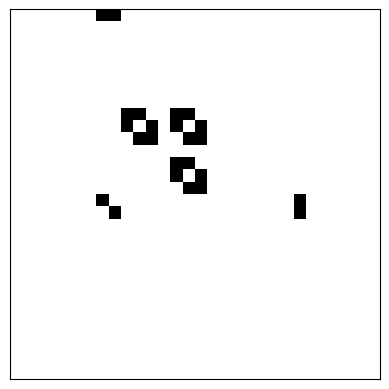

In [257]:
plot_checkerboard(lat_frames[1])


In [174]:
np.sum(spin_bin)

np.int64(0)

In [73]:
valid = (msg >= 0) & (msg <= np.log(H))
has_any = valid.any(axis=0)

# replace invalid entries by a huge number so min works
big = np.iinfo(np.int32).max
msg = np.asarray(msg, dtype=np.int32)
work = np.where( valid, msg, big)

# minimum valid message on each triangle
m = work.min(axis=0)   # shape (Lx, Ly)
min_mask = valid & (msg == m[None, :, :])   # shape (6, Lx, Ly)

up_raw    = min_mask[0] | min_mask[1]   # directions 1,2
right_raw = min_mask[2] | min_mask[3]   # directions 3,4
left_raw  = min_mask[4] | min_mask[5]   # directions 5,6

opposite_orientation_pair = (
        (min_mask[3] & min_mask[4]) |
        (min_mask[1] & min_mask[2]) |
        (min_mask[0] & min_mask[5])
)
# how many distinct spins are proposed?
n_props = (
    up_raw.astype(np.uint8)
    + right_raw.astype(np.uint8)
    + left_raw.astype(np.uint8)
)

# classify your three cases
# 0 = no valid message, 1/2/3 = number of distinct proposed spins
case = np.where(has_any, n_props, 0).astype(np.uint8)

# parity consistency with the syndrome
# accept iff (# proposed spins mod 2) == syndrome
accept = (case > 0) & ((n_props & 1) == b) & (~opposite_orientation_pair)
up_prop    = up_raw & accept
right_prop = right_raw & accept
left_prop  = left_raw & accept

print(accept)
print(up_prop)
print(right_prop)
print(left_prop)
print(b)
triangle_props_to_spin_union(up_prop, right_prop, left_prop)
print(opposite_orientation_pair)

[[ True  True  True False False False False False]
 [False  True  True False False False False False]
 [False False  True False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]]
[[False False False False False False False False]
 [False  True  True False False False False False]
 [False False  True False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]
 [False False False False False False False False]]
[[ True  True False False False False False False]
 [False  True False False False False False False]
 [False False False False False False False False]
 [False False False False Fal

In [176]:
print(msg[:,8,0])

[-1 -1  9 -1 -1 17]


In [74]:
np.sum(accept)

np.int64(6)

In [56]:
H, L = 10, 10
steps = 40
lattice = np.zeros((H, L), dtype=np.uint8)
# lattice[10, 0] = 1
# lattice[11, 1:4] = 1
# lattice[12, 1] = 1
# lattice[12, 3] = 1
# lattice[13, 2] = 1
# lattice[13, 3] = 1
# lattice[14, 3] = 1
lenth = 2
b = np.zeros((H,L))
b = compute_b_nm(lattice)
b[lenth,lenth] =1; b[1, lenth] = 1; b[lenth, 1] =1
Lx, Ly = b.shape
msg = np.full((6, Lx, Ly), -1, dtype=np.int16)
phi = np.full((H,L), -1, np.int16)
phi[b==1]=0
phi_frames = []
b_frames = []
for _ in range(steps):
    # b = compute_b_nm(lattice)
    # phi = step_phi_distance_nm(phi, b, cap=15)
    # phi_frames.append(phi)
    b_frames.append(b)

    msg = step_msgs_emit_from_defects(msg, b, cap=12)
    phi_frames.append(msg[4])
anim = animate_phi_with_defects(phi_frames, b_frames, interval=200, marker_size=40, return_anim=True)
from matplotlib.animation import FFMpegWriter
fps = 1  # higher = faster playback (for same number of frames)
writer = FFMpegWriter(fps=fps, bitrate=1800)

anim.save("animation.mp4", writer=writer, dpi=150)
print("Saved animation.mp4")


Saved animation.mp4


In [44]:
x, y = np.where(b == 1)
for i, j in zip(x, y):
    print(msg[:, (i+1)%H, j])

[ 1  3  3 10 10 10]
[ 1 10 10  1 10 10]
[ 1 10 10 10 10 10]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_checkerboard(q, ax=None, title=None):
    """
    Checkerboard-style plot for a 2D binary array q (values 0/1).
    Uses a 2-color discrete colormap + crisp square pixels.
    """
    q = np.asarray(q)
    if q.ndim != 2:
        raise ValueError("q must be 2D")
    if ax is None:
        fig, ax = plt.subplots()

    cmap = ListedColormap(["white", "black"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

    im = ax.imshow(q, origin="upper", interpolation="nearest", cmap=cmap, norm=norm)
    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title)
    return ax, im



In [9]:
def pascal_mod2_rows(num_rows: int, width: int | None = None) -> np.ndarray:
    """
    Build rows of (1+x)^n over GF(2).

    Output A has shape (num_rows, width), where
    A[n, k] = 1 iff coeff of x^k in (1+x)^n is 1 mod 2.
    """
    if width is None:
        width = num_rows

    A = np.zeros((num_rows, width), dtype=np.uint8)
    A[0, 0] = 1   # (1+x)^0 = 1

    for n in range(num_rows - 1):
        row = A[n]
        shifted = np.zeros_like(row)
        shifted[1:] = row[:-1]          # x * row
        A[n + 1] = row ^ shifted        # mod-2 addition

    return A

In [16]:
s = 32
lat = pascal_mod2_rows(s, s)
lattice = np.zeros((2*s,2*s))
lattice[s:2*s, s:2*s] = lat
lattice = np.transpose(lattice)
# b = compute_b_nm(lattice)
# print(b)

(<Axes: >, <matplotlib.image.AxesImage at 0x10d5cd6d0>)

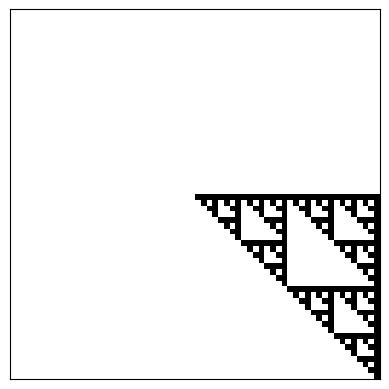

In [17]:
plot_checkerboard(lattice)

(<Axes: >, <matplotlib.image.AxesImage at 0x11089fd90>)

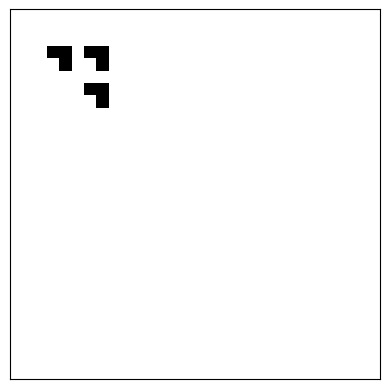

In [153]:
plot_checkerboard(b_frames[6])

(<Axes: >, <matplotlib.image.AxesImage at 0x1112a4550>)

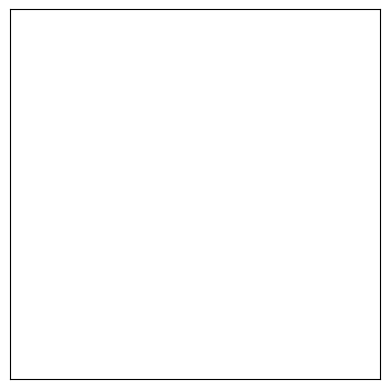

In [198]:
plot_checkerboard(lat_frames[2])

In [138]:
spin_union_accepted

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False,